# Optimized Polygon Specificity Plot — Tutorial

This notebook shows the **entire user-facing workflow** for the optimized polygon plot: starting from EMBER output you already have (`Psi_block` scores + p/q-values), producing the ILR -> PCA -> Procrustes-aligned polygon plot in one function call.

It's built to be run as-is, right now: this repo already has real EMBER output sitting in `../output_results/` from an earlier run (the kidney developmental atlas, partitioned by `Age`: `E16.5, P0, W3, W12, W52, W92`). That's a stand-in for "you already ran `light_ember` and `generate_pvals` on your own data" — the function doesn't care whether the partition is developmental age, mouse strain, cell type, or anything else.

**Run this notebook with its working directory set to `strain_polygon_analysis/`** (Jupyter's default when you open it from that folder) so the relative imports/paths below resolve.

## Step 0 — what you should already have

After running `light_ember(...)` (optionally with `partition_pvals=True`, or a separate `generate_pvals(...)` call), you have on disk:

- `Psi_block_df/mean_Psi_block_df_{partition_label}.csv` — one row per gene, one column per category, values sum to 1 across categories per gene.
- `pvals_entropy_metrics_{partition_label}.csv` — one row per gene, with `Psi`, `Psi p-value`, `Psi q-value` columns (plus `Zeta` columns, unused here).

That's it — that's the entire input. No config file, no extra preprocessing.

## Step 1 — peek at those two files

Just to make concrete what "EMBER output" means before we plot it.

In [1]:
import pandas as pd

partition_label = "Age"
psi_block_dir = "../output_results/Psi_block_df"
pvals_dir = "../output_results/pvals_entropy_metrics_Age.csv"

psi_block = pd.read_csv(f"{psi_block_dir}/mean_Psi_block_df_{partition_label}.csv", index_col=0)
pvals = pd.read_csv(pvals_dir, index_col=0)

print(psi_block.shape, "genes x categories")
display(psi_block.head())

print(pvals.shape, "genes x metrics")
display(pvals.head())

(16828, 6) genes x categories


,E16.5,P0,W12,W3,W52,W92
gene_ids,,,,,,
Xkr4,0.400437,0.242739,0.026898,0.044219,0.091016,0.194692
Rp1,0.019060,0.037020,0.248944,0.274953,0.203826,0.216197
Sox17,0.146582,0.230551,0.112812,0.286189,0.102718,0.121148
Mrpl15,0.160242,0.130006,0.185662,0.174369,0.155463,0.194258
Lypla1,0.081604,0.064161,0.228354,0.176952,0.233800,0.215130


(16828, 6) genes x metrics


,Psi,Psi p-value,Zeta,Zeta p-value,Psi q-value,Zeta q-value
gene_name,,,,,,
Xkr4,0.739546,0.000999,0.174786,0.000999,0.001551,0.001551
Rp1,0.677603,0.000999,0.144800,0.000999,0.001551,0.001551
Sox17,0.672865,0.045954,0.058505,0.000999,0.058756,0.001551
Mrpl15,0.749583,0.310689,0.008329,0.000999,0.326553,0.001551
Lypla1,0.799883,0.000999,0.056284,0.000999,0.001551,0.001551


## Step 2 — generate the plot: one function call

`plot_polygon_specificity` is written to match `ember_py`'s own function style exactly (it's meant to eventually live in `ember_py/plots.py` — see `polygon_specificity.py` in this folder). It takes the *paths* to the two files above, not the DataFrames — same convention as `plot_partition_specificity` / `plot_block_specificity` already in `ember_py`.

Required arguments are just: `partition_label`, `psi_block_dir` (the folder containing the `mean_Psi_block_df_*.csv`), `pvals_dir`, and `save_dir`. Everything else has a sensible default.

Genes passing p<0.05, q<0.05, Psi>0.6: 10071
ILR: 10071 genes x 6 categories -> 5 coords; PCA: PC1=78.9% PC2=7.8%
Searching 720 vertex permutations...


Best vertex order: ['P0', 'E16.5', 'W52', 'W92', 'W12', 'W3'] (residual=28.23280)


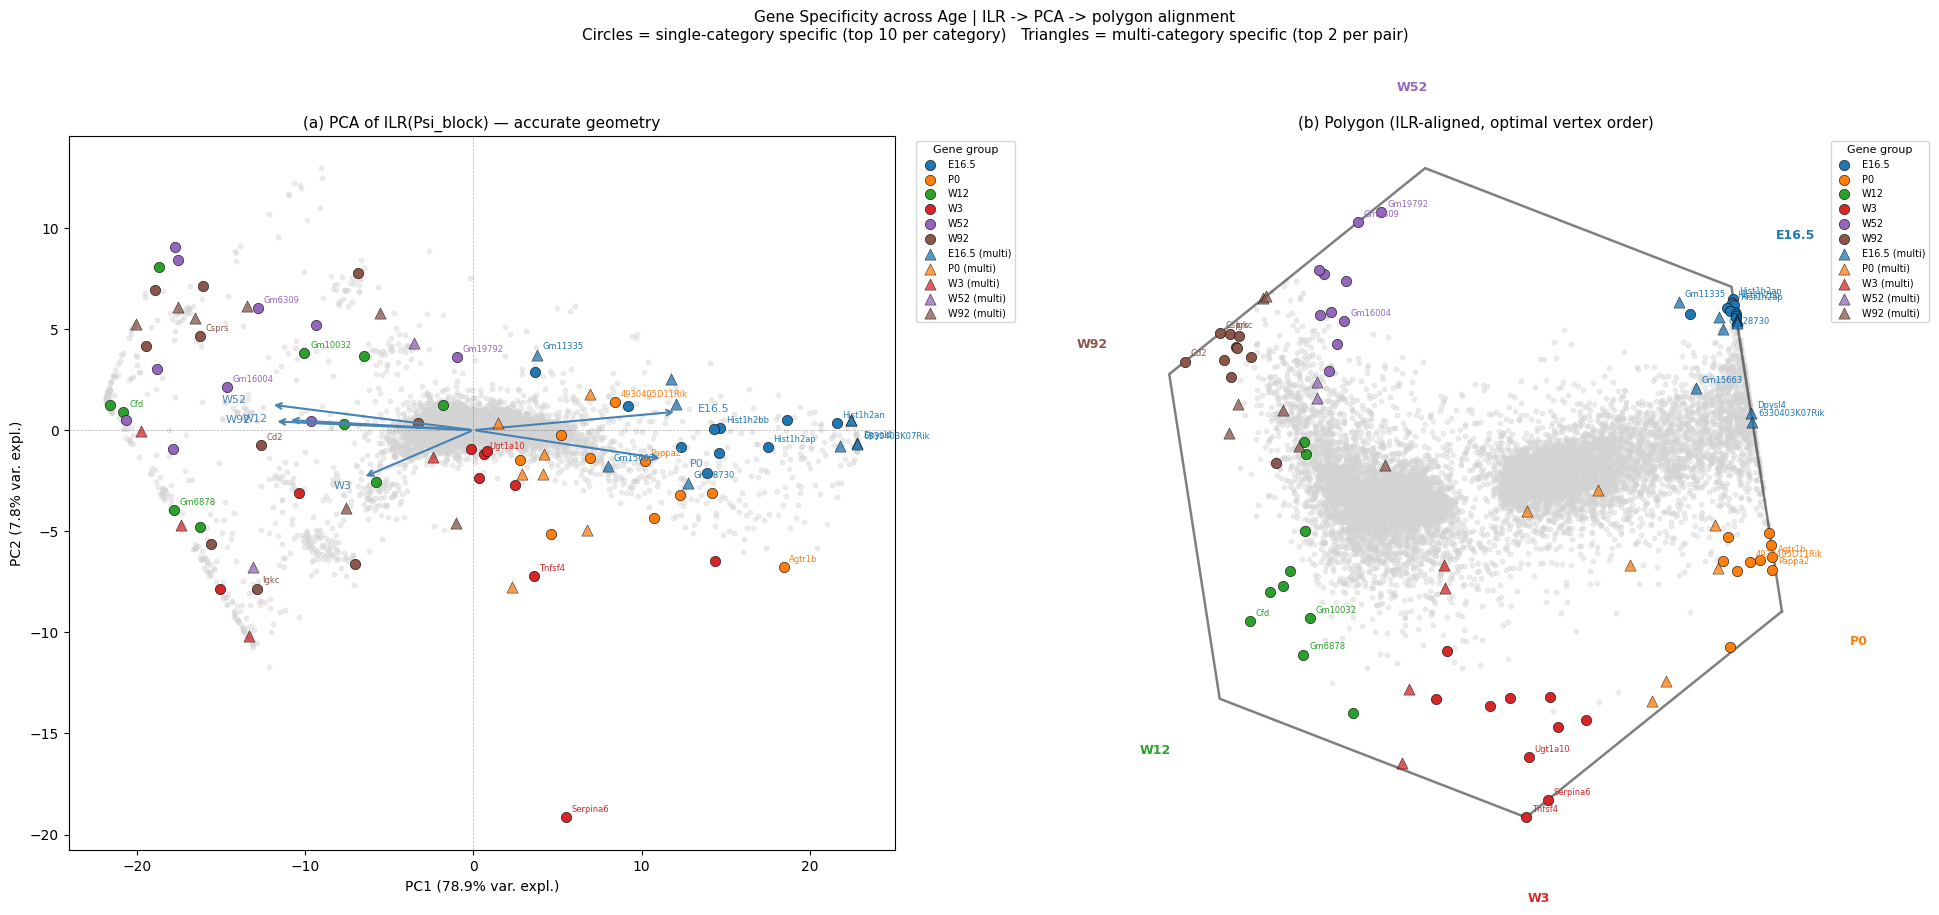

Polygon specificity plot saved to tutorial_output\polygon_specificity_Age.png
Highlighted gene table saved to tutorial_output\polygon_highlighted_genes_Age.csv
PCA coords saved to tutorial_output\polygon_pca_coords_Age.csv


In [2]:
from polygon_specificity import plot_polygon_specificity

plot_polygon_specificity(
    partition_label=partition_label,
    psi_block_dir=psi_block_dir,
    pvals_dir=pvals_dir,
    save_dir="tutorial_output",
)

That's the whole workflow. What just happened, and what the two panels mean:

- **Left panel (PCA)**: significant genes (filtered by `psi_thresh`/`p_thresh`/`q_thresh`) are ILR-transformed (maps the compositional `Psi_block` simplex into true Euclidean space) and projected to 2D via PCA. This is the "ground truth" gene geometry — biplot arrows show how each category correlates with PC1/PC2.
- **Right panel (Polygon)**: the same genes, but laid out on a regular polygon. Critically, the polygon's vertex order is *not* arbitrary — the function brute-force searched all `K!` category-to-vertex assignments and Procrustes-aligned the polygon to the PCA centroids each time, keeping whichever assignment geometrically matches the left panel best. That's the "optimized" part: an octagon/hexagon/etc. plot that's provably not just a nice-looking guess.
- Circles = genes specific to one category; triangles = genes shared between exactly two categories.

It also saved three files into `save_dir` (`tutorial_output/` here):
- `polygon_specificity_Age.png` — the figure itself
- `polygon_highlighted_genes_Age.csv` — which genes were highlighted and why
- `polygon_pca_coords_Age.csv` — every significant gene's ILR/PCA coordinates (not just the highlighted ones), if you want to build your own plot from the same coordinates

In [3]:
highlighted = pd.read_csv("tutorial_output/polygon_highlighted_genes_Age.csv")
highlighted.head(10)

,gene,group,rank_in_group,psi_max_category,psi_score
0,Hist1h2an,single_E16.5,1,E16.5,0.9626
1,Hist1h2bb,single_E16.5,2,E16.5,0.9498
2,Hist1h2ap,single_E16.5,3,E16.5,0.9430
3,Hist1h2ai,single_E16.5,4,E16.5,0.9252
4,Hist1h2af,single_E16.5,5,E16.5,0.9221
5,Hist1h2ab,single_E16.5,6,E16.5,0.9209
6,Rxfp2,single_E16.5,7,E16.5,0.9167
7,Gm15398,single_E16.5,8,E16.5,0.9087
8,Fbxo48,single_E16.5,9,E16.5,0.9060
9,Hist1h2ae,single_E16.5,10,E16.5,0.9032


## Optional: customizing

Everything below `save_dir` in the signature has a default, but all of it is overridable:

- `categories` — restrict to / reorder a subset of categories (color assignment / display only — doesn't change which vertex assignment is "best").
- `category_colors` — a `{category: color}` dict, instead of the default `tab10`/`tab20` colormap.
- `psi_thresh`, `p_thresh`, `q_thresh` — how strict the significance filter is before ILR/PCA.
- `n_single`, `n_per_pair`, `min_psi` — how many genes get highlighted, and how "clean" a single-category specificity has to be to count.
- `gene_symbol_lookup` — a `dict`/`pandas.Series` mapping index values to readable names, useful if your `Psi_block` index is Ensembl IDs rather than gene symbols.

Genes passing p<0.05, q<0.05, Psi>0.6: 10071
ILR: 10071 genes x 6 categories -> 5 coords; PCA: PC1=78.9% PC2=7.8%


Searching 720 vertex permutations...
Best vertex order: ['W52', 'W92', 'W12', 'W3', 'P0', 'E16.5'] (residual=27.93227)


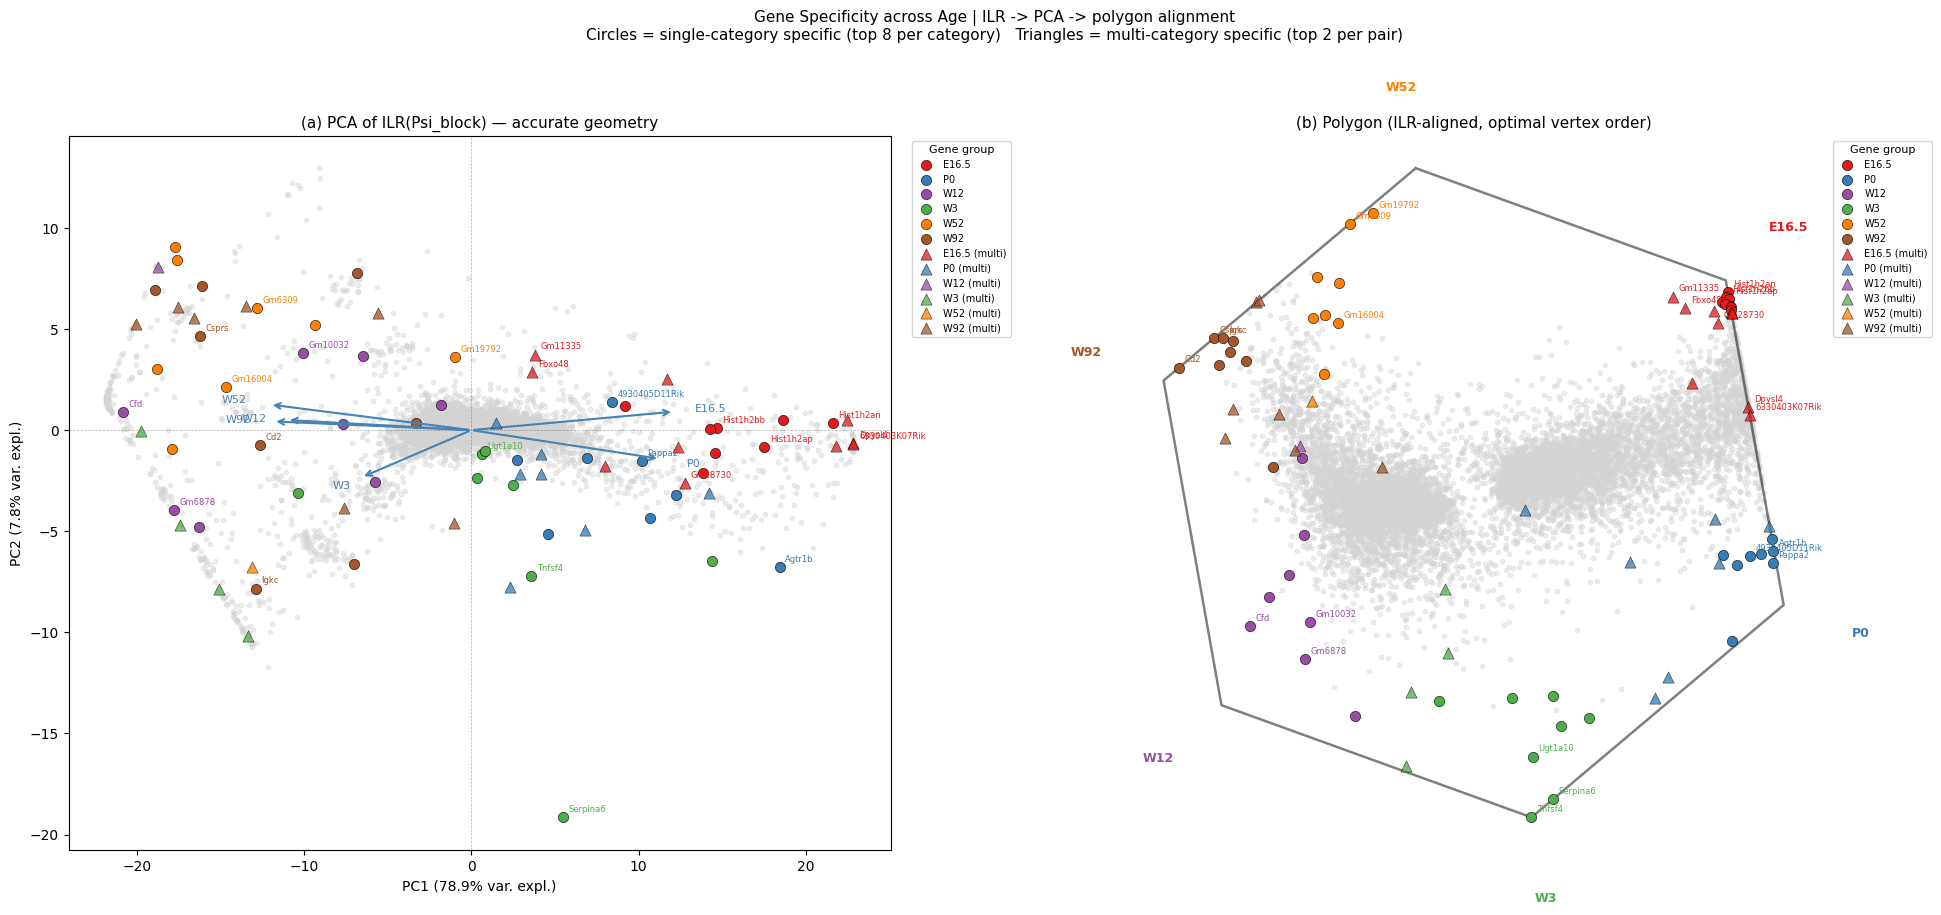

Polygon specificity plot saved to tutorial_output\polygon_specificity_Age.png
Highlighted gene table saved to tutorial_output\polygon_highlighted_genes_Age.csv
PCA coords saved to tutorial_output\polygon_pca_coords_Age.csv


In [4]:
plot_polygon_specificity(
    partition_label=partition_label,
    psi_block_dir=psi_block_dir,
    pvals_dir=pvals_dir,
    save_dir="tutorial_output",
    category_colors={
        "E16.5": "#E41A1C", "P0": "#377EB8", "W3": "#4DAF4A",
        "W12": "#984EA3", "W52": "#FF7F00", "W92": "#A65628",
    },
    psi_thresh=0.6,
    n_single=8,       # fewer highlighted genes per category than the default 10
)

## Where this goes next

Right now, `from polygon_specificity import plot_polygon_specificity` imports from this folder. Once this is contributed upstream, the only line that changes for any user is the import:

```python
from ember_py.plots import plot_polygon_specificity
```

Everything else — the call signature, the two files it needs, the outputs it produces — stays identical. That's the point of matching `ember_py`'s existing conventions this closely: there's no separate "polygon plot config" to learn, just one more function alongside `plot_partition_specificity` and `plot_block_specificity`.